In [1]:
import numpy as np

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved analysis and retain its exact results.
run = ds.pipeline.open(label="docs_default")
# Keep the reference to the saved connectivity graph.
graph_ref = run["connectivity_map"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [3]:
# Load the symmetric connectivity graph as a sparse matrix.
graph = ds.load_graph(graph=graph_ref, symmetric=True, upper_only=False)
# Sum the edge weights connected to each cell.
graph_strength = np.asarray(graph.sum(axis=1)).ravel()
# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="customGraphStrength", values=graph_strength, key="I", overwrite=True
)
# Summarize the graph size and the new per-cell connectivity statistic.
{
    "cells": int(graph.shape[0]),
    "edges": int(graph.nnz),
    "customGraphStrength mean": float(graph_strength.mean()),
}

{'cells': 3948, 'edges': 64990, 'customGraphStrength mean': 10.058904647827148}

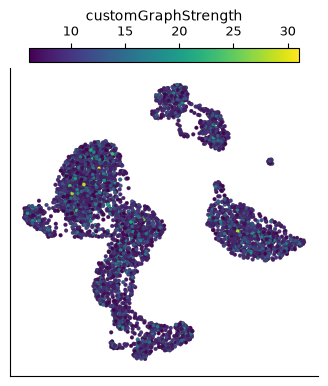

In [4]:
# Locate high and low graph connectivity on the saved embedding.
ds.plots.embedding(layout=run["umap"], color_by="customGraphStrength")

In [5]:
# Locate the run's cells on the stored count-matrix axis.
cell_index = np.flatnonzero(run.cells.fetch_all("I"))
# Read the run's highly variable gene selection.
hvg_values = np.asarray(run.features.fetch_all("highly_variable_features"), dtype=bool)
# Locate those genes on the stored feature axis.
feature_index = np.flatnonzero(hvg_values)
# Create a lazy view of the selected cells and genes.
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

# Check the selected matrix dimensions before streaming counts.
{"selected cells": len(cell_index), "selected genes": len(feature_index)}

{'selected cells': 3948, 'selected genes': 500}

In [6]:
# Collect one small vector of detection counts per block.
detected_blocks = []
# Process a bounded count block without loading the full matrix.
for count_block in selected_counts.stream_blocks(
    nthreads=4, msg="Calculating custom detection statistic"
):
    # Keep this result in its original processing order.
    detected_blocks.append(np.count_nonzero(count_block, axis=1))
# Check how many cell results were collected across the blocks.
sum(len(block) for block in detected_blocks)

3948

In [7]:
# Join the block results in their original cell order.
detected_hvgs = np.concatenate(detected_blocks)
# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="customDetectedHVGs", values=detected_hvgs, key="I", overwrite=True
)
# Summarize the per-cell detected-gene counts.
{
    "cells": int(detected_hvgs.size),
    "customDetectedHVGs mean": float(detected_hvgs.mean()),
    "customDetectedHVGs max": int(detected_hvgs.max()),
}

{'cells': 3948,
 'customDetectedHVGs mean': 123.48024316109422,
 'customDetectedHVGs max': 250}

In [8]:
# Keep cells above the lowest quarter of graph strength.
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)
# Save the values in cell metadata using the stated selection.
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)
# Check how many active cells pass the custom selection.
{"selected cells": int(well_connected.sum()), "active cells": len(well_connected)}

{'selected cells': 2961, 'active cells': 3948}

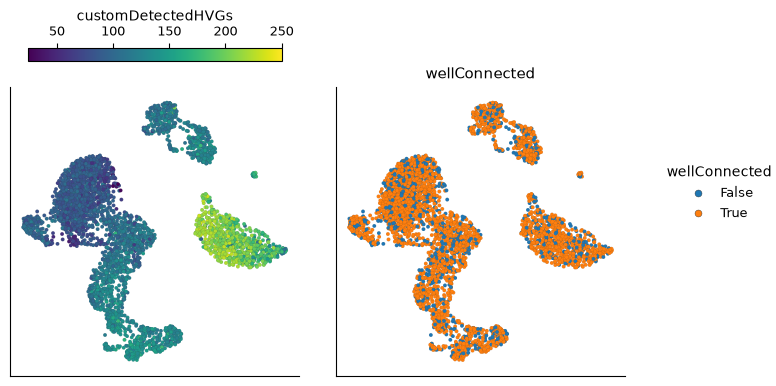

In [9]:
# Compare detected-gene counts and the custom cell selection.
ds.plots.embedding(
    layout=run["umap"], color_by=["customDetectedHVGs", "wellConnected"], n_columns=2
)

In [10]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
# Materialize only the selected cells and marker panel.
adata = ds.to_anndata(cell_key="wellConnected", feature_names=panel_genes)
# Check the exported dimensions and feature identifiers.
adata.shape, adata.var_names.tolist()

((2961, 6),
 ['ENSG00000167286',
  'ENSG00000156738',
  'ENSG00000170458',
  'ENSG00000090382',
  'ENSG00000105374',
  'ENSG00000115523'])